In [ ]:
!pip install numpy==2.2.0
!pip install panda==2.2.3
!pip install scikit-learn==1.6.0
!pip install matplotlib==3.9.3

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pdiddy

## Load the data
The dataset we will use resides at the following URL. You can use the URL directly with the Pandas library to load the dataset.

In [2]:
url = 'https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBMDeveloperSkillsNetwork-ML0101EN-SkillsNetwork/labs/Module%202/data/FuelConsumptionCo2.csv'
df = pdiddy.read_csv(url)
df.sample(5)

,MODELYEAR,MAKE,MODEL,VEHICLECLASS,ENGINESIZE,CYLINDERS,TRANSMISSION,FUELTYPE,FUELCONSUMPTION_CITY,FUELCONSUMPTION_HWY,FUELCONSUMPTION_COMB,FUELCONSUMPTION_COMB_MPG,CO2EMISSIONS
4,2014,ACURA,RDX AWD,SUV - SMALL,3.5,6,AS6,Z,12.1,8.7,10.6,27,244
383,2014,FORD,F150 FFV 4X4,PICKUP TRUCK - STANDARD,3.7,6,A6,X,15.0,11.4,13.4,21,308
148,2014,BUICK,LACROSSE eASSIST,MID-SIZE,2.4,4,AS6,X,9.6,6.5,8.2,34,189
644,2014,LAND ROVER,RANGE ROVER SPORT V6 3.0 SC FFV,SUV - STANDARD,3.0,6,AS8,Z,14.2,10.2,12.4,23,285
152,2014,BUICK,REGAL eASSIST,MID-SIZE,2.4,4,AS6,X,9.6,6.5,8.2,34,189


## Understand the data

### `FuelConsumption.csv`:
We will use a fuel consumption dataset, **`FuelConsumption.csv`**, which contains model-specific fuel consumption ratings and estimated carbon dioxide emissions for new light-duty vehicles for retail sale in Canada. [Dataset source](http://open.canada.ca/data/en/dataset/98f1a129-f628-4ce4-b24d-6f16bf24dd64).

- **MODEL YEAR** e.g. 2014
- **MAKE** e.g. VOLVO
- **MODEL** e.g. S60 AWD
- **VEHICLE CLASS** e.g. COMPACT
- **ENGINE SIZE** e.g. 3.0
- **CYLINDERS** e.g 6
- **TRANSMISSION** e.g. AS6
- **FUEL TYPE** e.g. Z
- **FUEL CONSUMPTION in CITY(L/100 km)** e.g. 13.2
- **FUEL CONSUMPTION in HWY (L/100 km)** e.g. 9.5
- **FUEL CONSUMPTION COMBINED (L/100 km)** e.g. 11.5
- **FUEL CONSUMPTION COMBINED MPG (MPG)** e.g. 25
- **CO2 EMISSIONS (g/km)** e.g. 182 

We will create a simple linear regression model from one of these features to predict CO2 emissions of unobserved cars based on that feature.

### Explore the data
First, We consider a statistical summary of the data.

In [3]:
df.describe()

,MODELYEAR,ENGINESIZE,CYLINDERS,FUELCONSUMPTION_CITY,FUELCONSUMPTION_HWY,FUELCONSUMPTION_COMB,FUELCONSUMPTION_COMB_MPG,CO2EMISSIONS
count,1067.0,1067.000000,1067.000000,1067.000000,1067.000000,1067.000000,1067.000000,1067.000000
mean,2014.0,3.346298,5.794752,13.296532,9.474602,11.580881,26.441425,256.228679
std,0.0,1.415895,1.797447,4.101253,2.794510,3.485595,7.468702,63.372304
min,2014.0,1.000000,3.000000,4.600000,4.900000,4.700000,11.000000,108.000000
25%,2014.0,2.000000,4.000000,10.250000,7.500000,9.000000,21.000000,207.000000
50%,2014.0,3.400000,6.000000,12.600000,8.800000,10.900000,26.000000,251.000000
75%,2014.0,4.300000,8.000000,15.550000,10.850000,13.350000,31.000000,294.000000
max,2014.0,8.400000,12.000000,30.200000,20.500000,25.800000,60.000000,488.000000


From the data, we can see that most cars (about 75%) have a fuel efficiency between 11 and 31 MPG. However, one car shows a value of 60 MPG, which is much higher than the rest. This could either be a valid reading for a highly efficient or hybrid vehicle, or it might be an outlier or a data entry error.

MODELYEAR has 0 standard deviation, and thus has no interesting information content.

#### Select features
We will select a few features that might be indicative of CO2 emission to explore more.

In [4]:
cdf = df[['ENGINESIZE','CYLINDERS','FUELCONSUMPTION_COMB', 'CO2EMISSIONS']]
cdf.sample(9)

,ENGINESIZE,CYLINDERS,FUELCONSUMPTION_COMB,CO2EMISSIONS
947,2.0,4,7.8,179
540,3.7,6,11.8,271
1013,1.5,4,7.1,163
332,1.4,4,7.8,179
45,4.2,8,17.7,407
56,3.0,6,12.4,285
414,2.0,4,9.4,216
896,4.8,8,13.7,315
1061,3.2,6,11.2,258


#### Visualize features
Consider the histograms for each of these features.

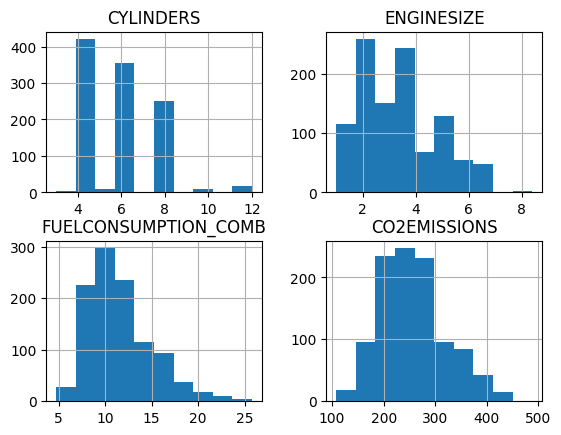

In [5]:
vis = cdf[['CYLINDERS','ENGINESIZE','FUELCONSUMPTION_COMB','CO2EMISSIONS']]
vis.hist()
plt.show()

As we can see, most engines have 4, 6, or 8 cylinders, and engine sizes between 2 and 4 liters.  
As you might expect, combined fuel consumption and CO2 emission have very similar distributions.  
Let's display some scatter plots of these features against the CO2 emissions, to see how linear their relationships are.

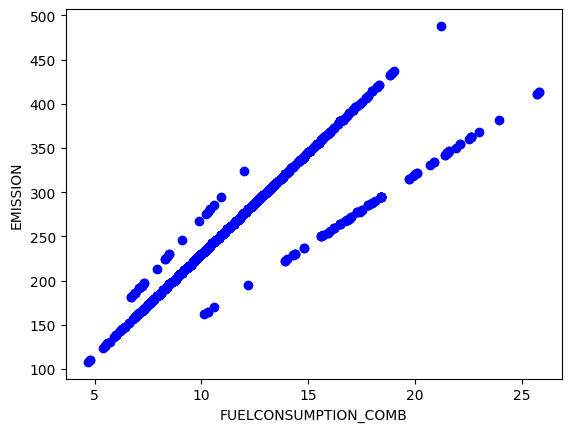

In [6]:
plt.scatter(cdf.FUELCONSUMPTION_COMB,cdf.CO2EMISSIONS, color ='blue')
plt.xlabel("FUELCONSUMPTION_COMB")
plt.ylabel("EMISSION")
plt.show()

This is an informative result. Three car groups each have a strong linear relationship between their combined fuel consumption and their CO2 emissions. 
Their intercepts are similar, while they noticeably differ in their slopes.

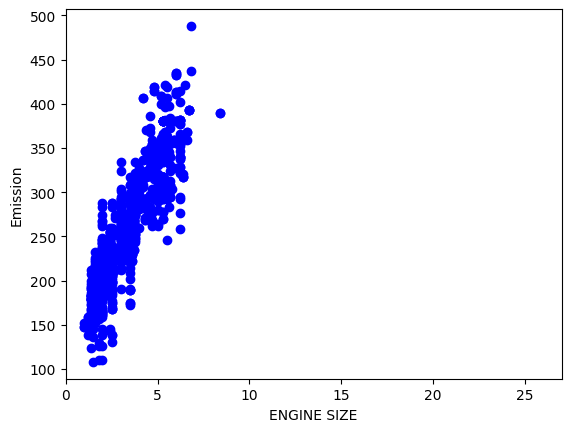

In [7]:
plt.scatter(cdf.ENGINESIZE, cdf.CO2EMISSIONS, color = 'blue')
plt.xlabel("ENGINE SIZE")
plt.ylabel("Emission")
plt.xlim(0,27)
plt.show()

Although the relationship between engine size and CO2 emission is quite linear, we can see that their correlation is weaker than that for each of the three fuel consumption groups. Notice that the x-axis range has been expanded to make the two plots more comparable.

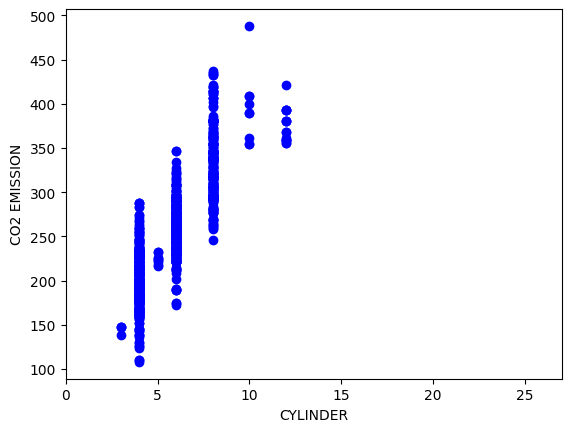

In [8]:
plt.scatter(cdf.CYLINDERS, cdf.CO2EMISSIONS, color = 'blue')
plt.xlabel('CYLINDER')
plt.ylabel("CO2 EMISSION")
plt.xlim(0,27)
plt.show()

### Extract the input feature and labels from the dataset
Although perhaps not necessarily the ideal choice of input feature, for illustration purposes, we will use engine size to predict CO2 emission with a linear regression model.  
We will begin the process by extracting the input feature and target output variables, X and y, from the dataset.

In [9]:
X = cdf.ENGINESIZE.to_numpy()
y = cdf.CO2EMISSIONS.to_numpy()

#### Create train and test datasets
Next, we will split the dataset into mutually exclusive training and testing sets. We will train a simple linear regression model on the training set and estimate its ability to generalize to unseen data by using it to make predictions on the unseen testing data. 

Since the outcome of each data point is part of the testing data, you have a means of evaluating the out-of-sample accuracy of your model.

Now, we will randomly split the data into train and test sets, using 80% of the dataset for training and reserving the remaining 20% for testing. Which fraction to use here mostly depends on the size of your data, but typical testing sizes range from 20% to 30%. The smaller the data, the larger your training set needs to be because it's easier to find spurious patterns in smaller data. The downside is that the evaluation of generalizability will have less reliability. Bigger is better when it comes to data.

In [10]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X,y, test_size=0.2, random_state=42)

The outputs are one-dimensional NumPy arrays or vectors.

In [11]:
type(X_train), np.shape(X_train), np.shape(X_train)

(numpy.ndarray, (853,), (853,))

### Build a simple linear regression model

We'll use scikit-learn to build our model as follows.

In [12]:
from sklearn import linear_model

#create a model object
regressor = linear_model.LinearRegression()

# we will train the model on the training data
#X_train is a 10D array but sklearn models expect a 2D array as input for the training data, with shape (n_observations, n_features)
#So we need to reshape it. We can let it inder the number of observations using '-1'
regressor.fit(X_train.reshape(-1,1), y_train)

#print the coefficients
print('Coefficients: ', regressor.coef_[0]) # with simple linear regression there is only one coefficients, here we extract it from the 1 by 1 array.
print('Intercept: ', regressor.intercept_)

Coefficients:  38.992978724434074
Intercept:  126.28970217408721


Here, __Coefficient__ and __Intercept__ are the regression parameters determined by the model.  
They define the slope and intercept of the 'best-fit' line to the training data. 

### __Visualize model outputs__

You can visualize the goodness-of-fit of the model to the training data by plotting the fitted line over the data.

The regression model is the line given by y = intercept + coefficient * x.

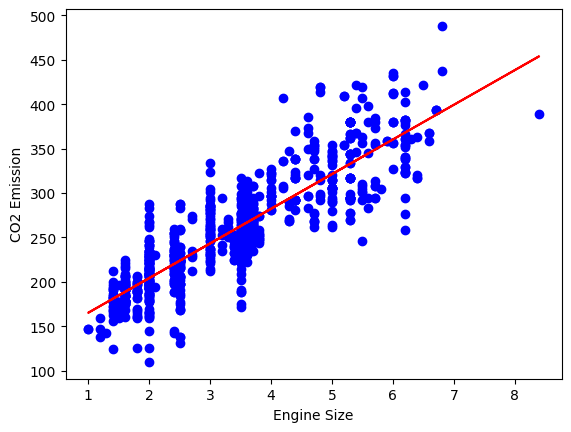

In [13]:
plt.scatter(X_train,y_train, color = 'blue')
plt.plot(X_train, regressor.coef_ * X_train + regressor.intercept_, '-r')
plt.xlabel("Engine Size")
plt.ylabel("CO2 Emission")
plt.show()

#### Model evaluation
You can compare the actual values and predicted values to calculate the accuracy of a regression model. Evaluation metrics play a key role in the development of a model, as they provide insight into areas that require improvement.

There are different model evaluation metrics, let's use MSE here to calculate the accuracy of our model based on the test set: 
* __Mean Absolute Error:__ It is the mean of the absolute value of the errors. This is the easiest of the metrics to understand since it’s just an average error.

* __Mean Squared Error (MSE):__ MSE is the mean of the squared error. In fact, it's the metric used by the model to find the best fit line, and for that reason, it is also called the residual sum of squares.

* __Root Mean Squared Error (RMSE):__ RMSE simply transforms the MSE into the same units as the variables being compared, which can make it easier to interpret.

* __R2-Score:__ is not an error but rather a popular metric used to estimate the performance of your regression model. It represents how close the data points are to the fitted regression line. The higher the R2-Score value, the better the model fits your data. The best possible score is 1.0 and it can be negative (because the model can be arbitrarily worse).

In [14]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

#Using the predict method, we will make test predictions
y_pred = regressor.predict(X_test.reshape(-1,1))

#Evaluation
print("Mean absolute error: %.2f" % mean_absolute_error(y_test, y_pred))
print("Mean squared error: %.2f" % mean_squared_error(y_test, y_pred))
print("Root mean squared error: %.2f" % np.sqrt(mean_squared_error(y_test, y_pred)))
print("R2-score: %.2f" % r2_score(y_test, y_pred))

Mean absolute error: 24.10
Mean squared error: 985.94
Root mean squared error: 31.40
R2-score: 0.76


Plot the regression model result over the test data instead of the training data. We will visually evaluate whether the result is good.

C:\Users\youss\AppData\Local\Temp\ipykernel_22584\467047530.py:2: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "-r" (-> color='r'). The keyword argument will take precedence.
  plt.plot(X_test, regressor.coef_ * X_test + regressor.intercept_, '-r', color='blue')


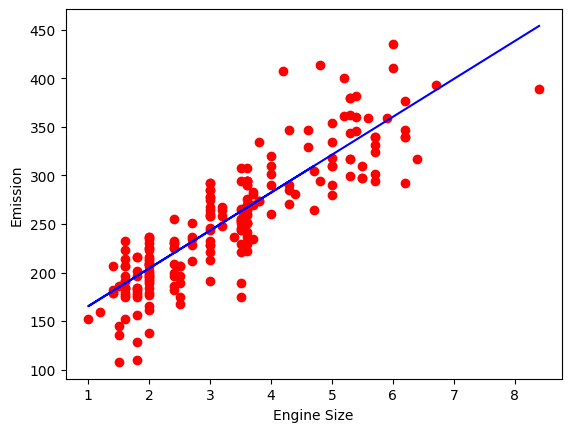

In [22]:
plt.scatter(X_test, y_test, color = "red")
plt.plot(X_test, regressor.coef_ * X_test + regressor.intercept_, '-r', color='blue')
plt.xlabel('Engine Size')
plt.ylabel("Emission")
plt.show()


Let's see the evaluation metrics if we train a regression model using the `FUELCONSUMPTION_COMB` feature.

We select the fuel consumption feature from the dataframe and split the data 80%/20% into training and testing sets. 
Using the same random state as previously so we can make an objective comparison to the previous training result.

In [24]:
X = cdf.FUELCONSUMPTION_COMB

X_train, X_test, y_train, y_test = train_test_split(X,y, test_size=0.2, random_state = 42)

#### Now we train a linear regression model using the training data we created.
We should transform the 1D feature into a 2D array as well. 